In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid")

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/RFM_Olist.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94720 entries, 0 to 94719
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_unique_id  94720 non-null  object 
 1   recency             94720 non-null  int64  
 2   frequency           94720 non-null  int64  
 3   monetary            94720 non-null  float64
 4   freight_ratio       94720 non-null  float64
 5   avg_review_score    94720 non-null  float64
dtypes: float64(3), int64(2), object(1)
memory usage: 4.3+ MB


In [ ]:
df.head(5)

,customer_unique_id,recency,frequency,monetary,freight_ratio,avg_review_score
0,0000366f3b9a7992bf8c76cfdf3221e2,115,1,141.90,0.0846,5.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,118,1,27.19,0.3049,4.0
2,0000f46a3911fa3c0805444483337064,541,1,86.22,0.1997,3.0
3,0000f6ccb0745a6a4b88665a16c9f078,325,1,43.62,0.4042,4.0
4,0004aac84e0df4da2b147fca70cf8255,292,1,196.89,0.0858,5.0


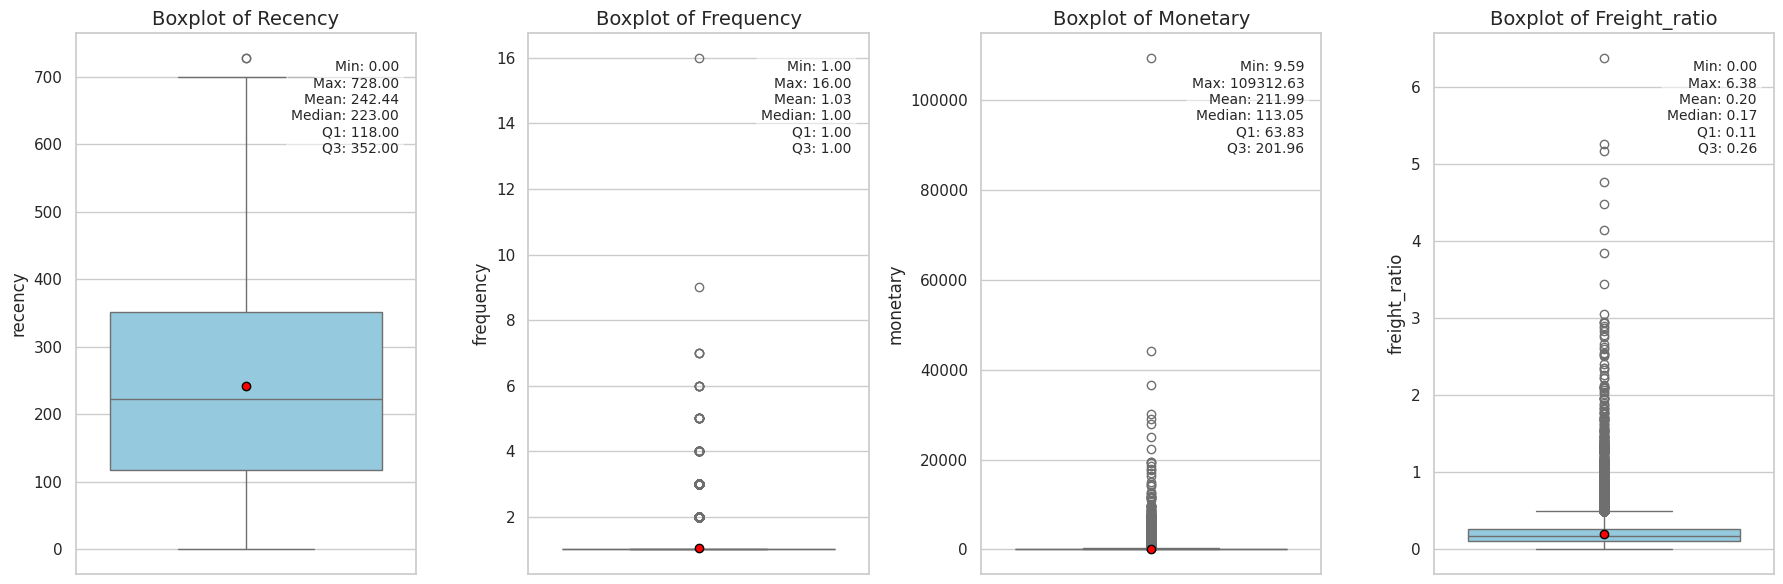

In [ ]:
cols = ['recency', 'frequency', 'monetary','freight_ratio']
fig, axes = plt.subplots(1, 4, figsize=(18, 6))

for i, col in enumerate(cols):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue', showmeans=True,
                meanprops={'marker':'o', 'markerfacecolor':'red', 'markeredgecolor':'black'})
    axes[i].set_title(f'Boxplot of {col.capitalize()}', fontsize=14)


    stats = df[col].describe()
    min_val = stats['min']
    max_val = stats['max']
    mean_val = stats['mean']
    median_val = stats['50%']
    q1 = stats['25%']
    q3 = stats['75%']


    text_str = (f'Min: {min_val:.2f}\n'
                f'Max: {max_val:.2f}\n'
                f'Mean: {mean_val:.2f}\n'
                f'Median: {median_val:.2f}\n'
                f'Q1: {q1:.2f}\n'
                f'Q3: {q3:.2f}')

    axes[i].text(0.95, 0.95, text_str, transform=axes[i].transAxes,
                 fontsize=10, verticalalignment='top', horizontalalignment='right',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

df['R_log'] = np.log(df['recency'] + 1)
df['F_log'] = np.log(df['frequency'])
df['M_log'] = np.log(df['monetary'] + 1)
df['freight_log'] = np.log(df['freight_ratio'] + 1)



In [ ]:
df.rename(columns={'R_log': 'R', 'F_log': 'F', 'M_log': 'M','freight_log':'Fr'}, inplace=True)
df.head()

,customer_unique_id,recency,frequency,monetary,freight_ratio,avg_review_score,R,F,M,Fr
0,0000366f3b9a7992bf8c76cfdf3221e2,115,1,141.90,0.0846,5.0,4.753590,0.0,4.962145,0.081211
1,0000b849f77a49e4a4ce2b2a4ca5be3f,118,1,27.19,0.3049,4.0,4.779123,0.0,3.338967,0.266126
2,0000f46a3911fa3c0805444483337064,541,1,86.22,0.1997,3.0,6.295266,0.0,4.468434,0.182072
3,0000f6ccb0745a6a4b88665a16c9f078,325,1,43.62,0.4042,4.0,5.786897,0.0,3.798182,0.339468
4,0004aac84e0df4da2b147fca70cf8255,292,1,196.89,0.0858,5.0,5.680173,0.0,5.287711,0.082317


In [ ]:
features = ['R', 'F', 'M', 'Fr']
X = df[features]

# Khởi tạo Scaler
scaler = StandardScaler()

# Fit và Transform dữ liệu
X_scaled = scaler.fit_transform(X)

# Chuyển lại thành DataFrame để dễ nhìn (tùy chọn)
df_scaled = pd.DataFrame(X_scaled, columns=features)

In [ ]:
df_scaled.head(5)

,R,F,M,Fr
0,-0.511513,-0.17304,0.164540,-0.882302
1,-0.482616,-0.17304,-1.624263,0.785865
2,1.233282,-0.17304,-0.379549,0.027584
3,0.657935,-0.17304,-1.118191,1.447496
4,0.537149,-0.17304,0.523326,-0.872327


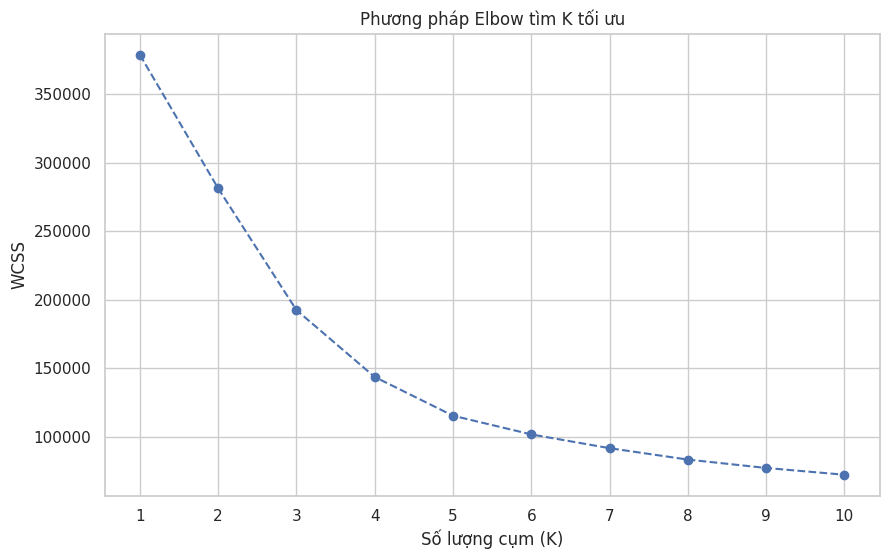

In [ ]:
wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Vẽ biểu đồ Elbow
plt.figure(figsize=(10, 6))
plt.plot(K_range, wcss, marker='o', linestyle='--')
plt.title('Phương pháp Elbow tìm K tối ưu')
plt.xlabel('Số lượng cụm (K)')
plt.ylabel('WCSS')
plt.xticks(K_range)
plt.show()

In [ ]:
# K = 4: 0.354
# K = 5: 0.327
# Chọn K = 4
optimal_k = 4
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)

# Dự đoán và gán nhãn
cluster_labels = kmeans_final.fit_predict(X_scaled)

# Gắn nhãn vào DataFrame gốc
df['Cluster'] = cluster_labels



In [ ]:
df.head(5)

,customer_unique_id,recency,frequency,monetary,freight_ratio,avg_review_score,R,F,M,Fr,Cluster
0,0000366f3b9a7992bf8c76cfdf3221e2,115,1,141.90,0.0846,5.0,4.753590,0.0,4.962145,0.081211,2
1,0000b849f77a49e4a4ce2b2a4ca5be3f,118,1,27.19,0.3049,4.0,4.779123,0.0,3.338967,0.266126,1
2,0000f46a3911fa3c0805444483337064,541,1,86.22,0.1997,3.0,6.295266,0.0,4.468434,0.182072,1
3,0000f6ccb0745a6a4b88665a16c9f078,325,1,43.62,0.4042,4.0,5.786897,0.0,3.798182,0.339468,1
4,0004aac84e0df4da2b147fca70cf8255,292,1,196.89,0.0858,5.0,5.680173,0.0,5.287711,0.082317,2


In [ ]:
# Tính trung bình các chỉ số theo từng cụm
cluster_profile = df.groupby('Cluster').agg({
    'recency': 'mean',
    'frequency': 'mean',
    'monetary': 'mean',
    'freight_ratio': 'mean',
    'Cluster': 'count' # Đếm số lượng khách hàng trong mỗi cụm
}).rename(columns={'Cluster': 'Num_Customers'}).round(2)

print(cluster_profile)

         recency  frequency  monetary  freight_ratio  Num_Customers
Cluster                                                            
0          48.48       1.00    158.63           0.20          16412
1         285.44       1.00     62.18           0.33          33221
2         285.15       1.00    334.19           0.11          42218
3         225.54       2.11    453.54           0.19           2869


In [ ]:
# Tạo từ điển map tên nhóm
cluster_mapping = {
    0: 'Recent Customers',
    1: 'Price-Sensitive Churners',
    2: 'High-Ticket One-Offs',
    3: 'Sleeping VIPs'
}

# Tạo cột mới với tên nhóm
df['Customer_Segment'] = df['Cluster'].map(cluster_mapping)

output_df = df[['customer_unique_id', 'recency', 'frequency', 'monetary', 'freight_ratio', 'Customer_Segment']]

output_df.to_csv('olist_customer_segments.csv', index=False, encoding='utf-8')